A 的形状: (50, 2)
拟合结果: 截距 = 1.097, 斜率 = 1.978
真实值:   截距 = 1.000, 斜率 = 2.000


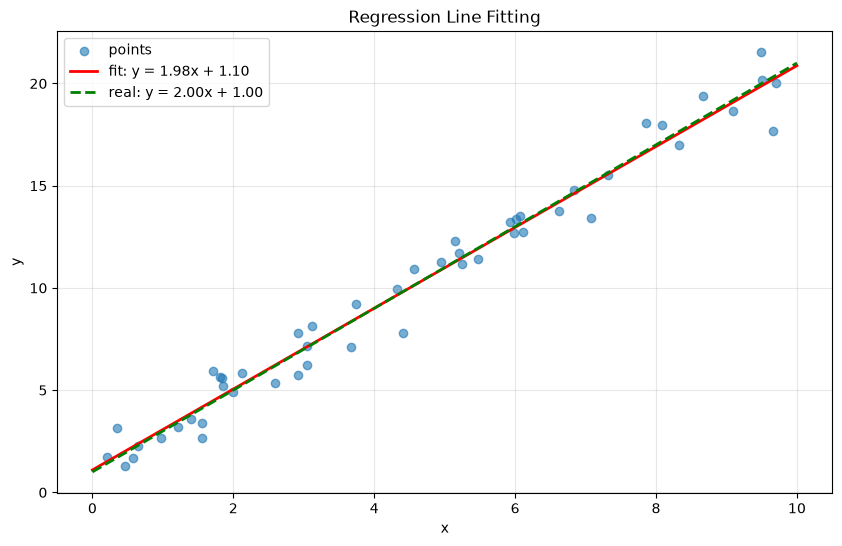


残差的均方根误差 (RMSE): 0.907
残差的均值: 0.000 (应该接近0)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 生成数据：y = 2*x + 1 + 噪声 ----
np.random.seed(42)
n_points = 50
x = np.random.uniform(0, 10, n_points)
true_slope = 2.0
true_intercept = 1.0
noise = np.random.normal(0, 1.0, n_points)
y = true_intercept + true_slope * x + noise

# ---- 构建矩阵 A ----
# 每一行是 [1, x_i]
A = np.column_stack([np.ones(n_points), x])
b = y

print("A 的形状:", A.shape)  # (50, 2)

# ---- 用最小二乘求解 ----
c, m = np.linalg.lstsq(A, b, rcond=None)[0]  # 返回 (系数, 残差, 秩, 奇异值)
print(f"拟合结果: 截距 = {c:.3f}, 斜率 = {m:.3f}")
print(f"真实值:   截距 = {true_intercept:.3f}, 斜率 = {true_slope:.3f}")

# ---- 画图 ----
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='points')

# 拟合直线
x_plot = np.linspace(0, 10, 100)
y_plot = c + m * x_plot
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'fit: y = {m:.2f}x + {c:.2f}')

# 真实直线（用于对比）
y_true = true_intercept + true_slope * x_plot
plt.plot(x_plot, y_true, 'g--', linewidth=2, label=f'real: y = {true_slope:.2f}x + {true_intercept:.2f}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Regression Line Fitting')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---- 残差分析 ----
residuals = y - (c + m * x)  # 每个点的误差
print(f"\n残差的均方根误差 (RMSE): {np.sqrt(np.mean(residuals**2)):.3f}")
print(f"残差的均值: {np.mean(residuals):.3f} (应该接近0)")